# Class/Backend Processor

In [2]:
import numpy as np
import qutip as qt
from qutip import gates
from qutip_qip import *
from qiskit import QuantumCircuit
from qutip_qip.qiskit import QiskitCircuitSimulator
from qiskit.visualization import plot_histogram
from qutip_qip.device import LinearSpinChain
from qutip_qip.qiskit import QiskitPulseSimulator
from qutip_qip.device import Processor, Model
from qutip_qip.operations import rx
import warnings
warnings.filterwarnings('ignore')

In [3]:
from qiskit.compiler import transpile
from qutip_qip.circuit import QubitCircuit
from qutip_qip.qiskit.converter import convert_qiskit_circuit
from qiskit.visualization import plot_histogram

In [4]:
class minimal_processor( Processor ):
    def __init__(self, num_qubits=2, num_levels=4, decay_rate=1/(540e-6)):
        self.model = Model(2)
        self.num_qubits = num_qubits
        self.decay_rate = decay_rate
        self.native_gates = ["rx", "rz", "cz"]
        # basis states
        self.s0 = qt.tensor(qt.fock(2,0),qt.fock(2,0))
        self.s1 = qt.tensor(qt.fock(2,0),qt.fock(2,1))
        self.sr = qt.tensor(qt.fock(2,1),qt.fock(2,0))
        self.sd = qt.tensor(qt.fock(2,1),qt.fock(2,1))
        self.states = [self.s0, self.s1, self.sr, self.sd]
        self.b_0r = 1/16
        self.b_1r = 1/16
        self.b_dr = 7/8
        self.final_unitary_t = qt.tensor([qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(self.num_qubits)])
        self.circuit = None
        return

    def make_zero_density_matrix(self):
        zero_state = qt.tensor([qt.tensor(qt.zero_ket(2),qt.zero_ket(2)) for x in range(2)])
        return zero_state*zero_state.dag()

    def make_unitary_for_Qcircuit(self, index, partial_unitary, control_gate=False):
        if self.num_qubits == 1: return partial_unitary
        else:
            if control_gate: 
                tot_qubits = self.num_qubits - 1
                if tot_qubits == 1: return partial_unitary
            else: tot_qubits = self.num_qubits
            gates = [qt.tensor(qt.qeye(2),qt.qeye(2)) for x in range(tot_qubits)]
            gates[index] = partial_unitary
            return qt.tensor(gates)

    def calculate_system_H(self, Omega_01, delta_1, Omega_r, Delta_r):
        return

    def make_collapse_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            gamma_r = self.decay_rate
            s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            L0 = np.sqrt(self.b_0r*gamma_r) * s0*sr.dag()
            L1 = np.sqrt(self.b_1r*gamma_r) * s1*sr.dag()
            Ld = np.sqrt(self.b_dr*gamma_r) * sd*sr.dag()
            operators += [self.make_unitary_for_Qcircuit(qn, L) for L in [L0, L1, Ld]]
        return operators

    def make_expectation_operators(self):
        operators = []
        for qn in range(self.num_qubits):
            #s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
            operators += [self.make_unitary_for_Qcircuit(qn, s*s.dag()) for s in self.states]
        return operators
    
    def RX_gate(self, angle, target, rho):
        Omega_0 = 1e6
        phi = 0.0 if angle > 0 else np.pi
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        pulse_width = abs(angle) / Omega_0
        def Omega_01(t, t0, sigma): 
            return Omega_0 * np.exp( -np.pow((t - t0), 2) / (2*sigma**2) )
        tot_t = pulse_width
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / 1000
        times = np.linspace(0.0, tot_t, steps+1) # This should be 10 seconds of microseconds?
        def H_Rx_gate(t):
            H = (Omega_01(t, midpoint_t, pulse_width) / 2) * np.cos(phi) * (s0*s1.dag() + s1*s0.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rx_gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rx_gate, angle*1e-6)
        return result

    def RZ_gate(self, angle, target, rho):
        # Constants
        Omega_0 = 0
        delta_1 = 0
        Omega_r = 0
        Delta_r = 0
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        c_ops_input = self.make_collapse_operators()
        e_ops_input = self.make_expectation_operators()
        T = angle/2*1e-6
        def delta_1_t(t):
            if 0 <= t < T: return 1e6
            else: return 0
        tot_t = T
        midpoint_t = tot_t / 2
        steps = 1000
        dt = tot_t / steps
        times = np.linspace(0.0, tot_t, steps+1)
        def H_Rz_Gate(t):
            H = (delta_1_t(t)*s0*s0.dag()) - (delta_1_t(t)*s1*s1.dag())
            return self.make_unitary_for_Qcircuit(target, H)
        result = qt.mesolve(H_Rz_Gate, rho, times, c_ops=c_ops_input, e_ops=e_ops_input, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_Rz_Gate, angle*1e-6)
        return result#, unitary_t

    def CZ_gate(self, control, target, rho):
        # Constants
        T = 0.54e-6 # (microseconds^-1) period
        t0_0 = (T/2)
        t0_1 = t0_0 + T
        Omega_01 = 0 #MHz
        delta_1= 0 #MHz
        Omega_r= 2*np.pi*17e6 #MHz
        Delta_r= 2*np.pi*23e6 #MHz
        s0, s1, sr, sd = self.s0, self.s1, self.sr, self.sd
        tau = .175 * T
        def Omega_1r_t(t):
            if t < T/2: t0 = t0_0
            else: t0 = t0_1
            a = np.exp(-(t0/tau)**4)
            Omega_1r = Omega_r * (np.exp(-((t-t0)**4) / tau**4) - a) / (1-a)
            return Omega_1r
        def Delta_r_t(t):
            t = t % (T/2)
            return -Delta_r * np.cos((2*np.pi / T) * t)
        c_ops = self.make_collapse_operators()
        e_ops = self.make_expectation_operators()
        #B = 2*np.pi*201.32753861e6 # MHz
        B = 2*np.pi*1000e6 # MHz
        def H_CZ(t):
            H_B = B * qt.tensor([sr,sr])*qt.tensor([sr,sr]).dag()
            H0 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H1 = ((Omega_01 / 2) * (s0*s1.dag() + s1*s0.dag())) + (delta_1*s1*s1.dag()) + ((Omega_1r_t(t)/2) * (s1*sr.dag() + (sr*s1.dag()))) + (Delta_r_t(t)*sr*sr.dag())
            H = qt.tensor([H0, qt.tensor(qt.qeye(2), qt.qeye(2))]) + qt.tensor([qt.tensor(qt.qeye(2), qt.qeye(2)), H1]) + H_B
            if control < target: return self.make_unitary_for_Qcircuit(control, H, control_gate=True)
            else: return self.make_unitary_for_Qcircuit(target, H, control_gate=True)
        tot_t = T
        steps = 1000
        dt = tot_t / steps
        tot_t = tot_t - dt
        times = np.linspace(0.0, tot_t, steps+1)
        result = qt.mesolve(H_CZ, rho, times, c_ops=c_ops, e_ops=e_ops, options={"store_states" : True, "store_final_state" : True})
        #unitary_t = qt.propagator(H_CZ, T, options={"nsteps":100000})
        return result#, unitary_t

    def generate_init_processor_state(self):
        list_qubit_states = [qt.tensor(qt.fock(2,0),qt.fock(2,0)) for x in range(self.num_qubits)]
        return qt.tensor(list_qubit_states)

    def load_circuit(self, qutip_circuit):
        print("Circuit Loaded")
        #print(qutip_circuit.gates)
        self.circuit = qutip_circuit
        return 

    def run_state(self, init_state, qutip_circuit=None):
        result = None
        curr_state = init_state
        if len(self.circuit.gates) == 0:
            result = self.RX_gate(0, 0, curr_state)
        else: 
            for gate in self.circuit.gates:
                H = 0
                #print(gate.name, gate.arg_value)
                if gate.name == "RX": result = self.RX_gate(gate.arg_value, gate.targets[0], curr_state)
                elif gate.name == "RZ": result = self.RZ_gate(gate.arg_value, gate.targets[0], curr_state)
                elif gate.name == "CZ": result = self.CZ_gate(gate.controls[0], gate.targets[0], curr_state)
                else: print("Incompatiable Gate")
                curr_state = result.final_state
            #self.final_unitary_t = self.final_unitary_t * unitary_t
        #print(result.final_state)
        return result

    def get_final_circuit_state(self, final_state):
        dims_list = [2*x+1 for x in range(self.num_qubits)]
        return final_state.ptrace(dims_list)

# Randomized Bench Dependencies

In [199]:
import numpy as np
from qiskit_experiments.library import StandardRB, InterleavedRB
from qiskit_experiments.framework import ParallelExperiment, BatchExperiment
import qiskit.circuit.library as circuits

# Exercise 3

In [327]:
processor1Q = minimal_processor(1)
backend1Q = QiskitPulseSimulator(processor1Q)

In [334]:
#lengths = np.arange(1, 10, 1)
lengths = np.arange(1, 10, 1)
num_samples = 10
seed = 1010
qubits = [0]

In [335]:
exp1 = StandardRB(qubits, lengths, num_samples=num_samples, seed=seed)
exp1.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

exp1._set_backend(backend1Q)
exp1._finalize()

transpiled_circuits = exp1._transpiled_circuits()
print(transpiled_circuits[0])

experimental_data = exp1._initialize_experiment_data()
run_opts = exp1.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [exp1._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: 3π/2
        ┌──────────┐┌───────┐ ░ ┌──────────┐┌───────┐ ░ ┌─┐
     q: ┤ Rz(-π/2) ├┤ Rx(π) ├─░─┤ Rz(-π/2) ├┤ Rx(π) ├─░─┤M├
        └──────────┘└───────┘ ░ └──────────┘└───────┘ ░ └╥┘
meas: 1/═════════════════════════════════════════════════╩═
                                                         0 
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circuit Loaded
Circui

In [336]:
experimental_data.add_jobs(jobs)

In [337]:
exp1.analysis.run(experimental_data)

ExperimentData(StandardRB, a6c19f8a-94e0-4659-b3fe-ec88e306a7d0, job_ids=['300c180b-9fae-43d7-8cc1-290460f1d4d8', '6f173f73-4b23-4da3-86e5-eb66d954a6f3', '5f37cb11-c5c6-4a87-a825-b50b8d2b2f95', 'e4fdbb56-26e1-4d7f-89b8-3660e455bb56', 'f2eef814-d442-4827-99f6-9c308a3cf9b9', 'f5475560-5abf-4e20-8600-8d0ded3cb2f8', '9dd43a49-283b-4d5d-96f7-802680e59672', 'ab718dae-df8c-44b9-9efa-c9c588a03765', '0d42e6ce-36ef-414f-a172-76322bdcd17d', '43cb0918-3b8d-4de6-b505-6bc595a852eb', '44f727e3-a815-4b4e-89e4-1a5e76a09b41', 'a73f2801-5832-4b0e-a1fc-b5f8aea0e3a3', 'ff352d49-2611-4b0b-ab0c-c3d8c166e917', 'd23d30ae-c6ec-4351-8524-63493c11d486', 'fe6238d0-a358-4d32-9cfb-76ab03bdffa7', '7314d8b7-6ec7-4850-bc00-a8b9d5bcb0c1', 'd86a0e10-a7d5-4fc3-8829-324a46a4a2f8', '043c00be-fbf0-4601-beba-3f8b5b1a9138', 'ed043732-05b3-4b84-8c72-6f12251f369b', '9a6969dc-2f48-409f-932b-b03c5fcb8463', '67011353-6688-45f4-bea5-1f0e11bbc80b', '82f436d9-bdef-4d49-ae4f-92e565e0d2cb', 'ed09de3b-358c-4911-8752-e09822725ebf', 'fab07

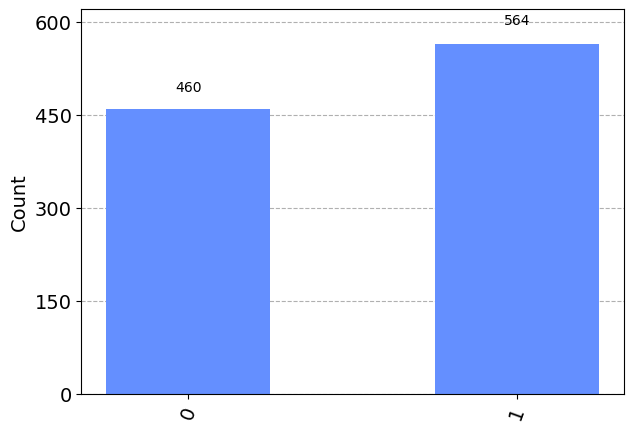

In [338]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

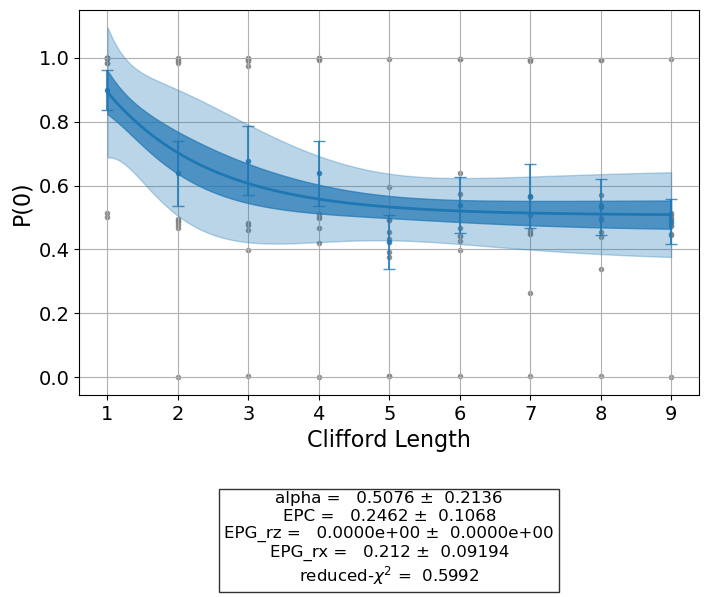

In [339]:
display(experimental_data.figure(0))

In [340]:
display(experimental_data.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq
c1a4c646,@Parameters_RBAnalysis,StandardRB,[Q0],CurveFitResult:\n - fitting method: least_squa...,good,pulse_simulator,None,None
ae5cbf40,alpha,StandardRB,[Q0],0.51+/-0.21,good,pulse_simulator,None,0.599234
49b861bf,EPC,StandardRB,[Q0],0.25+/-0.11,good,pulse_simulator,None,0.599234
7e572a13,EPG_rz,StandardRB,[Q0],0.0+/-0,good,pulse_simulator,None,0.599234
35d3b972,EPG_rx,StandardRB,[Q0],0.21+/-0.09,good,pulse_simulator,None,0.599234


# Exercise 4

In [341]:
processor2Q = minimal_processor(2)
backend2Q = QiskitPulseSimulator(processor2Q)

In [342]:
np.arange(1, 10, 10)

array([1])

In [359]:
lengths_2_qubit = np.arange(1, 2, 1)
lengths_1_qubit = np.arange(1, 2, 1)
num_samples = 10
seed = 1010
qubits = (1, 2)

In [360]:
exp2 = StandardRB(qubits, lengths, num_samples=num_samples, seed=seed)
exp2.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

exp2._set_backend(backend2Q)
exp2._finalize()

transpiled_circuits = exp2._transpiled_circuits()
print(transpiled_circuits[0])

experimental_data2 = exp2._initialize_experiment_data()
run_opts = exp2.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [exp2._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: π/4
                                                                             »
   q_0: ─────────────────────────────────────────────────────────────────────»
        ┌─────────┐                         ┌─────────┐┌─────────┐┌─────────┐»
   q_1: ┤ Rz(π/2) ├───────────────────────■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        ├─────────┤┌─────────┐┌─────────┐ │ ├─────────┤├─────────┤├─────────┤»
   q_2: ┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        └─────────┘└─────────┘└─────────┘   └─────────┘└─────────┘└─────────┘»
meas: 2/═════════════════════════════════════════════════════════════════════»
                                                                             »
«                                                                       »
«   q_0: ───────────────────────────────────────────────────────────────»
«           ┌─────────┐  ┌───────┐            ░ ┌──────────┐┌──────────┐»
«   q_1: ─■─┤ Rz(π/2) ├──┤ Rx(π) ├────────────░─┤

In [361]:
experimental_data2.add_jobs(jobs, timeout=None)

In [362]:
exp2.analysis.set_options(outcome="0")

In [363]:
expdata1_2q = exp2.analysis.run(experimental_data2, gate_error_ratio=False)

In [364]:
results1_2q = expdata1_2q.analysis_results()

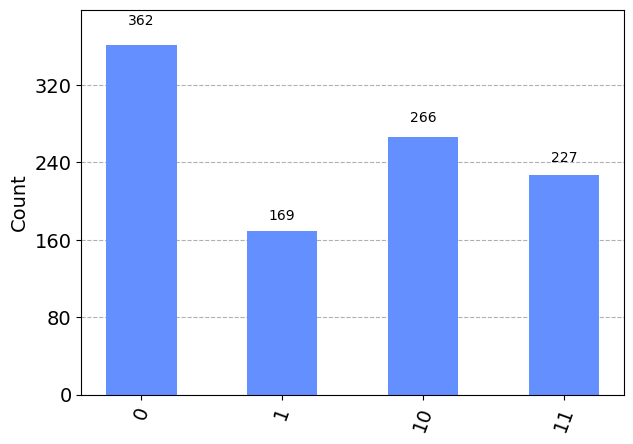

In [365]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

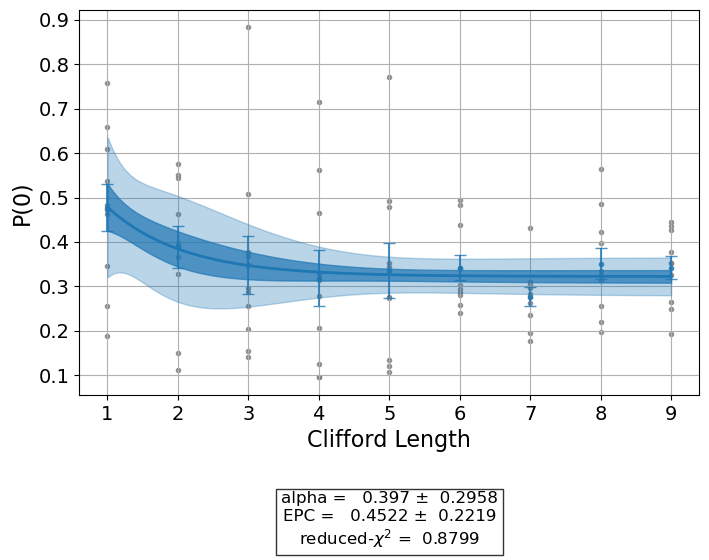

In [366]:
display(experimental_data2.figure(0))

In [367]:
display(experimental_data2.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq
67a6f289,@Parameters_RBAnalysis,StandardRB,"[Q1, Q2]",CurveFitResult:\n - fitting method: least_squa...,good,pulse_simulator,None,None
73d3be97,alpha,StandardRB,"[Q1, Q2]",0.40+/-0.30,good,pulse_simulator,None,0.879904
bae847e8,EPC,StandardRB,"[Q1, Q2]",0.45+/-0.22,good,pulse_simulator,None,0.879904


If my original fidelity for CZ was correct at .9 then it should be roughly 1/.9 clifford length. But most likely it is closer to .5 then length 2 seems correct. Honestly the length measurement was rather unclear from the docs and I mostly had to assume 1 or zero for most values correlated to our rx and rz gates.

The population is less in the zero state and clearly a much higher error (bad quality fit). It should be comparable to my orginal fidelity as well which does seem to be the case based on how I initially defined it in module 2. I also got around .2 fidelity for the gate there as well before ptracing

# Exercise 5

In [368]:
processor2Q = minimal_processor(2)
backend2Q = QiskitPulseSimulator(processor2Q)

In [370]:
lengths = np.arange(1, 4, 1)
num_samples = 10
seed = 1010
qubits = (1, 2)

# The interleaved gate is the CX gate
int_exp2 = InterleavedRB(circuits.CZGate(), qubits, lengths, num_samples=num_samples, seed=seed)
int_exp2.set_transpile_options(optimization_level=1, basis_gates=["rx", "rz", "cz"])

int_exp2._set_backend(backend2Q)
int_exp2._finalize()

transpiled_circuits = int_exp2._transpiled_circuits()
print(transpiled_circuits[0])

int_expdata2 = int_exp2._initialize_experiment_data()
run_opts = int_exp2.run_options.__dict__
_ = [this_circ.remove_final_measurements() for this_circ in transpiled_circuits]
jobs = [int_exp2._run_jobs(this_circ, **run_opts)[0] for this_circ in transpiled_circuits]

for i,job in enumerate(jobs):
    print("Job {} Done".format(i))
    d = job.result().results[0].header.to_dict()
    d["metadata"] = transpiled_circuits[i].metadata
    job.result().results[0].header.from_dict(d)

global phase: π/4
                                                                             »
   q_0: ─────────────────────────────────────────────────────────────────────»
        ┌─────────┐                         ┌─────────┐┌─────────┐┌─────────┐»
   q_1: ┤ Rz(π/2) ├───────────────────────■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        ├─────────┤┌─────────┐┌─────────┐ │ ├─────────┤├─────────┤├─────────┤»
   q_2: ┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├─■─┤ Rz(π/2) ├┤ Rx(π/2) ├┤ Rz(π/2) ├»
        └─────────┘└─────────┘└─────────┘   └─────────┘└─────────┘└─────────┘»
meas: 2/═════════════════════════════════════════════════════════════════════»
                                                                             »
«                                                                       »
«   q_0: ───────────────────────────────────────────────────────────────»
«           ┌─────────┐  ┌───────┐            ░ ┌──────────┐┌──────────┐»
«   q_1: ─■─┤ Rz(π/2) ├──┤ Rx(π) ├────────────░─┤

In [371]:
int_expdata2.add_jobs(jobs, timeout=None)

In [372]:
int_exp2.analysis.set_options(outcome="0")

In [373]:
int_expdata2_2q = int_exp2.analysis.run(int_expdata2, gate_error_ratio=False)

In [374]:
int_results1_2q = int_expdata2_2q.analysis_results()

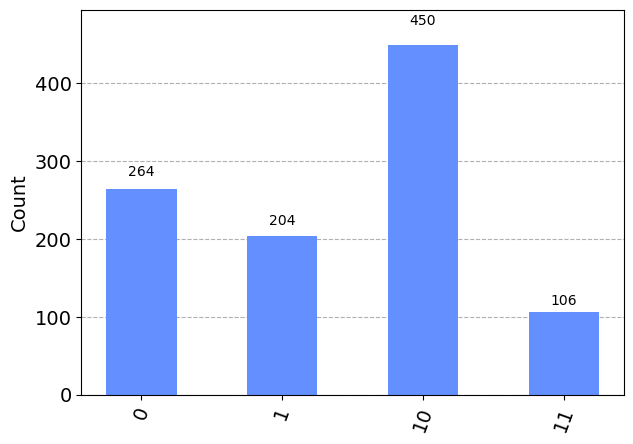

In [375]:
pulse_result = job.result()
plot_histogram(pulse_result.get_counts())

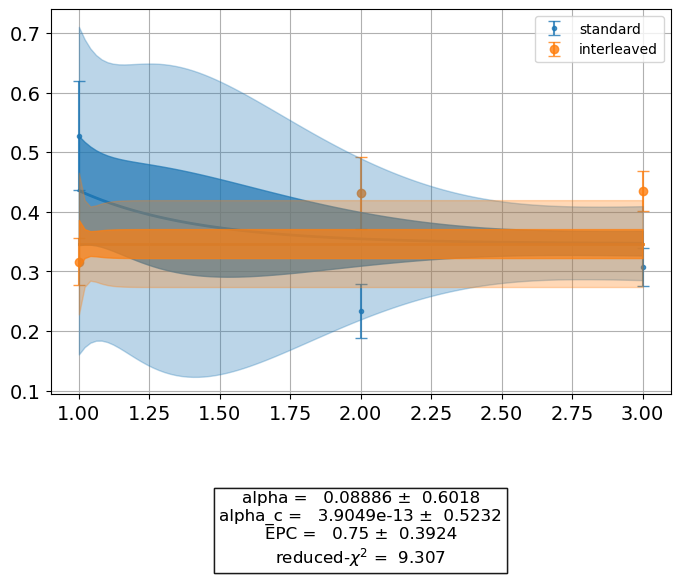

In [376]:
display(int_expdata2.figure(0))

In [377]:
display(int_expdata2.analysis_results(dataframe=True))

,name,experiment,components,value,quality,backend,run_time,chisq,EPC_systematic_err,EPC_systematic_bounds
4d9f75f4,@Parameters_InterleavedRBAnalysis,InterleavedRB,"[Q1, Q2]",CurveFitResult:\n - fitting method: least_squa...,bad,pulse_simulator,None,None,None,None
bd3f9123,alpha,InterleavedRB,"[Q1, Q2]",0.1+/-0.6,bad,pulse_simulator,None,9.306653,None,None
f3d6b29f,alpha_c,InterleavedRB,"[Q1, Q2]",0.0+/-0.5,bad,pulse_simulator,None,9.306653,None,None
76290951,EPC,InterleavedRB,"[Q1, Q2]",0.7+/-0.4,bad,pulse_simulator,None,9.306653,0.75,"[0.0, 1.4999999999994142]"
